In [17]:
import pandas as pd
from datetime import datetime
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
data= pd.read_csv("D:\\online_retail_II.csv")
df=data.copy()
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085.0,Germany
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,Germany
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085.0,Germany
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085.0,Germany
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085.0,Germany


In [149]:
pip install nbconvert[webpdf]

   ---------------------------------------- 0.0/30.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.0 MB ? eta -:--:--
   - -------------------------------------- 0.8/30.0 MB 3.4 MB/s eta 0:00:09
   - -------------------------------------- 1.3/30.0 MB 2.6 MB/s eta 0:00:12
   -- ------------------------------------- 2.1/30.0 MB 2.9 MB/s eta 0:00:10
   --- ------------------------------------ 2.6/30.0 MB 2.8 MB/s eta 0:00:10
   --- ------------------------------------ 2.9/30.0 MB 2.7 MB/s eta 0:00:11
   ---- ----------------------------------- 3.4/30.0 MB 2.6 MB/s eta 0:00:11
   ----- ---------------------------------- 4.2/30.0 MB 2.8 MB/s eta 0:00:10
   ------ --------------------------------- 5.2/30.0 MB 3.0 MB/s eta 0:00:09
   -------- ------------------------------- 6.3/30.0 MB 3.2 MB/s eta 0:00:08
   --------- ------------------------------ 7.1/30.0 MB 3.4 MB/s eta 0:00:07
   ---------- ----------------------------- 8.1/30.0 MB 3.4 MB/s eta 0:00:07
   ----------

In [64]:
df.shape

(1048575, 8)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1048575 non-null  object 
 1   StockCode    1048575 non-null  object 
 2   Description  1044203 non-null  object 
 3   Quantity     1048575 non-null  int64  
 4   InvoiceDate  1048575 non-null  object 
 5   Price        1048575 non-null  float64
 6   CustomerID   811893 non-null   float64
 7   Country      1048575 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 64.0+ MB


In [68]:
df=df.dropna(subset=['CustomerID'])
df.CustomerID= df.CustomerID.astype('int64')

In [70]:
df.describe()

,Quantity,Price,CustomerID
count,811893.000000,811893.000000,811893.000000
mean,12.422211,3.689914,15324.712265
std,141.686387,70.743669,1697.033034
min,-74215.000000,0.000000,12346.000000
25%,2.000000,1.250000,13971.000000
50%,5.000000,1.950000,15260.000000
75%,12.000000,3.750000,16795.000000
max,74215.000000,38970.000000,18287.000000


In [72]:
df=df[df["Quantity"]>0]

In [74]:
df.duplicated().any()

True

In [76]:
df.drop_duplicates(inplace=True)
df.shape

(767439, 8)

In [78]:
filtered_data=df[['CustomerID','Country']].drop_duplicates()
print(filtered_data.head())
filtered_data.shape

    CustomerID  Country
0        13085  Germany
12       13078  Germany
31       15362  Germany
54       18102  Germany
71       12682   France


(5876, 2)

<Axes: xlabel='Country'>

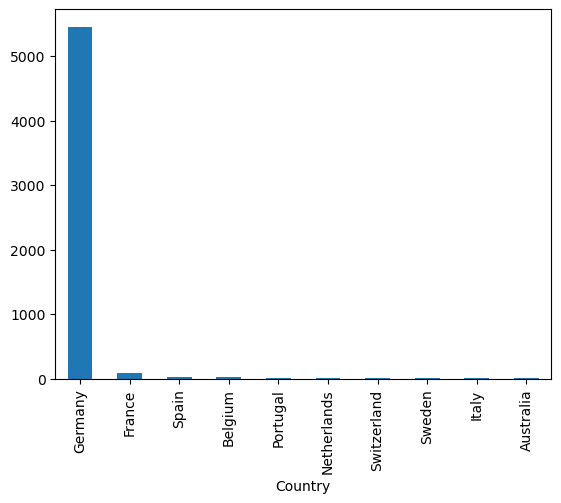

In [80]:
filtered_data.Country.value_counts()[:10].plot(kind='bar')

In [84]:
Ge_data=df[df['Country']=='Germany']
Ge_data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/1/2009 7:45,6.95,13085,Germany
1,489434,79323P,PINK CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085,Germany
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/1/2009 7:45,6.75,13085,Germany
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/1/2009 7:45,2.10,13085,Germany
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/1/2009 7:45,1.25,13085,Germany


In [94]:
Ge_data=Ge_data[['CustomerID','Invoice','InvoiceDate','Quantity','Price']]
Ge_data['TotalPrice']= Ge_data['Quantity']*Ge_data['Price']
Ge_data['InvoiceDate']= pd.to_datetime(Ge_data['InvoiceDate'],format='%m/%d/%Y %H:%M')
Ge_data.head()

,CustomerID,Invoice,InvoiceDate,Quantity,Price,TotalPrice
0,13085,489434,2009-12-01 07:45:00,12,6.95,83.4
1,13085,489434,2009-12-01 07:45:00,12,6.75,81.0
2,13085,489434,2009-12-01 07:45:00,12,6.75,81.0
3,13085,489434,2009-12-01 07:45:00,48,2.10,100.8
4,13085,489434,2009-12-01 07:45:00,24,1.25,30.0


In [98]:
present_time = datetime.now()

In [124]:
rfm=Ge_data.groupby('CustomerID').agg({"InvoiceDate":lambda date: (present_time-date.max()).days,
                                       'Invoice':lambda num : len(num),
                                       'TotalPrice':lambda price:price.sum()})
rfm.head()

,InvoiceDate,Invoice,TotalPrice
CustomerID,,,
12346,5054,34,77556.46
12426,4923,77,1345.21
12427,4750,31,825.80
12468,4916,150,3670.74
12471,4739,1098,37679.68


In [126]:
rfm.columns = ["Recency", "Frequency", "Monetary"] 

In [128]:
rfm['r_quartile'] = pd.qcut(rfm['Recency'], 4, ['1','2','3','4'])
rfm['f_quartile'] = pd.qcut(rfm['Frequency'], 4, ['4','3','2','1'])
rfm['m_quartile'] = pd.qcut(rfm['Monetary'], 4, ['4','3','2','1'])
rfm.head()


,Recency,Frequency,Monetary,r_quartile,f_quartile,m_quartile
CustomerID,,,,,,
12346,5054,34,77556.46,3,3,1
12426,4923,77,1345.21,3,2,2
12427,4750,31,825.80,1,3,3
12468,4916,150,3670.74,3,1,1
12471,4739,1098,37679.68,1,1,1


In [130]:
rfm["rfm_Score"] = rfm.r_quartile.astype(str) + rfm.f_quartile.astype(str) +rfm.m_quartile.astype(str)
rfm.head()

,Recency,Frequency,Monetary,r_quartile,f_quartile,m_quartile,rfm_Score
CustomerID,,,,,,,
12346,5054,34,77556.46,3,3,1,331
12426,4923,77,1345.21,3,2,2,322
12427,4750,31,825.80,1,3,3,133
12468,4916,150,3670.74,3,1,1,311
12471,4739,1098,37679.68,1,1,1,111


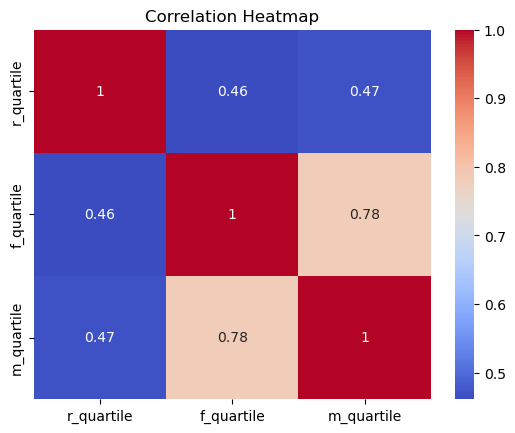

In [138]:
sns.heatmap(rfm[['r_quartile', 'f_quartile', 'm_quartile']].corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()
